### XY Chain: uniform angles → non-zero coupling 

Entropy estimates for a 1D classical XY chain using trained with Z_2 × U(1) equivariant optimal transport (OT) coupling.

### 0. Imports & environment

In [1]:
# --- imports & environment ---
import sys
import pathlib

import numpy as np
import torch
import matplotlib.pyplot as plt
from scipy.special import iv
import scipy.stats

plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']
plt.rcParams['font.size'] = 9

# Make the `eesi` package importable whether the notebook is launched from the
# repo root or from this experiments/ folder (no install required).
_cwd = pathlib.Path.cwd()
for _root in (_cwd, _cwd.parent, _cwd.parent.parent):
    if (_root / "eesi" / "__init__.py").exists():
        sys.path.insert(0, str(_root))
        break

# The new training hooks: dataset + sampler + model + coupled training step/loop.
from eesi.systems.xy.train import load_exact_data, sample_base, make_model, train
from eesi.systems.xy.ot import xy_ot_couple
from eesi.systems.xy.gnn import angle_wrap
from eesi import CHECKPOINTS_DIR,DATA_DIR

%matplotlib inline
torch.seed()
np.random.seed()
torch.set_default_dtype(torch.float64)   # the train hooks default to float64
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


#### 0.1. Some useful functions

In [2]:
def wrap(a):
    return (a + np.pi) % (2 * np.pi) - np.pi

def dtheta(x):                       # wrapped nearest-neighbour angle differences
    return wrap(x[:, 1:] - x[:, :-1]).reshape(-1).cpu().numpy()

def chain_energy(x, J):              # E = -J * sum_i cos(dtheta_i)
    return (-J * torch.cos(wrap(x[:, 1:] - x[:, :-1])).sum(-1)).cpu().numpy()

### 1. Datasets & samplers

`load_exact_data` generates samples from the **target** `p₁` by sampling the von Mises distribution. 
`sample_base` is the **base** `p₀`: independent uniform angles, drawn each step. Both have symmetry Z2 × U(1).


In [3]:
N = 10           # chain length
J = 2.0          # ferromagnetic coupling of the target Boltzmann distribution

x1_all = load_exact_data(N,J,10_000,seed=8).to(device)
n_data = x1_all.shape[0]
print("target dataset:", tuple(x1_all.shape))
print("sampled energy:", chain_energy(x1_all, J).mean().round(3)/N)

# Exact per-spin energy change (I_1/I_0 Bessel ratio) for reference.
dE = (N - 1) * (-J * (iv(1, J) / iv(0, J))) / N
print(f"exact energy  : {dE:+.4f}  (per spin)")

target dataset: (10000, 10)
sampled energy: -1.2559
exact energy  : -1.2560  (per spin)


### 2. Model setup


In [4]:
# Changing the batch size changes the x0/x1 coupling distribution and therefore
# the time-dependent marginals. So it's important to keep this constant across
# training and sampling.
batch_size = 256
torch.manual_seed(6)

# Model definition
model = make_model(
    n_neighbors=2, hidden=16, mlp_layers=3, n_layers=3, edge_order=8, time_order=8,
    path="linear", gamma="sqrt", gamma_scale=0.2,
    score_div_method="exact",
).to(device)
print("net_b params:", sum(p.numel() for p in model.net_b.parameters()))
print("net_s params:", sum(p.numel() for p in model.net_s.parameters()))

# optionally load from a saved checkpoint
model.net_b.load_state_dict(torch.load(CHECKPOINTS_DIR / "xy" / 'xy_b_N10.pth',weights_only=True))
model.net_s.load_state_dict(torch.load(CHECKPOINTS_DIR / "xy" / 'xy_s_N10.pth',weights_only=True))


net_b params: 3488
net_s params: 3488


<All keys matched successfully>

### 3. Training with equivariant OT

`train` runs the update loop: each step draws a target minibatch (from the existing dataset, not re-sampled) and a fresh base batch, applies `xy_ot_couple`, and minimises the velocity + score losses. 

We leave `batch_ot` = False since we wish to transfer this model to systems with different size (N) later on. This controls only the minibatch OT (i.e. index reshuffling to minimize batch transport cost). Each sample individually is still optimally aligned over its the Z2 × U(1) symmetry group (though this can be turned off if desired).

In [ ]:

model, total_hist = train(
    x1_all, model=model,
    steps=20_000, batch=batch_size, lr=1e-4, batch_ot=False,
    device=str(device), seed=49, log_every=1000, entropy="both",
)

model, hist = train(
    x1_all, model=model,
    steps=5_000, batch=batch_size, lr=1e-5, batch_ot=False,
    device=str(device), seed=49, log_every=1000, entropy="both",
)
total_hist += hist

torch.save(model.net_b.state_dict(), CHECKPOINTS_DIR / "xy" / 'xy_b_N10.pth')
torch.save(model.net_s.state_dict(), CHECKPOINTS_DIR / "xy" / 'xy_s_N10.pth')


  step     0  loss_b    0.0016  loss_s   -0.0021  S_dot    0.0000  S_zdot    0.0019  transport   5.864  (  0.0s)
  step  1000  loss_b   -1.8829  loss_s   -2.3422  S_dot   -3.0180  S_zdot   -3.4478  transport   5.774  ( 17.5s)
  step  2000  loss_b   -2.5149  loss_s   -3.5212  S_dot   -4.5374  S_zdot   -4.7002  transport   5.761  ( 36.0s)
  step  3000  loss_b   -2.6058  loss_s   -3.7427  S_dot   -4.7389  S_zdot   -4.8512  transport   5.743  ( 55.4s)
  step  4000  loss_b   -2.6184  loss_s   -3.9201  S_dot   -4.8408  S_zdot   -5.0015  transport   5.948  ( 74.9s)
  step  5000  loss_b   -2.6433  loss_s   -4.0141  S_dot   -4.9097  S_zdot   -5.0229  transport   5.888  ( 94.2s)
  step  6000  loss_b   -2.6585  loss_s   -4.2008  S_dot   -5.0200  S_zdot   -5.0915  transport   5.631  (114.1s)
  step  7000  loss_b   -2.6485  loss_s   -4.2861  S_dot   -5.0175  S_zdot   -5.0568  transport   5.848  (134.0s)
  step  8000  loss_b   -2.6661  loss_s   -4.3585  S_dot   -5.0471  S_zdot   -5.1093  transport  

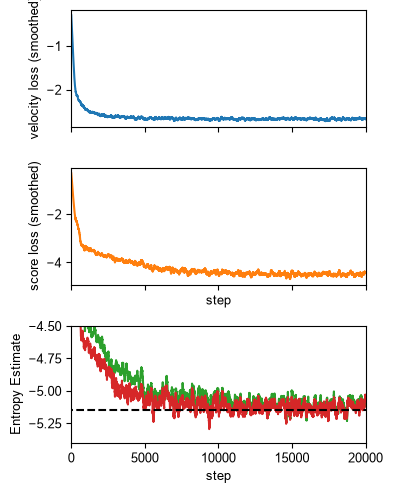

In [17]:
# Training curves (smoothed).
def smooth(v, k=100):
    v = np.asarray(v)
    return np.convolve(v, np.ones(k) / k, mode="valid") if len(v) >= k else v

hist_b, hist_s, ent_dot, ent_zdot = map(np.asarray, zip(*total_hist))

fig, ax = plt.subplots(3, 1, sharex=True, figsize=(4, 5))
ax[0].plot(smooth(hist_b), "-C0")
ax[0].set_ylabel("velocity loss (smoothed)")
ax[1].plot(smooth(hist_s), "-C1")
ax[1].set_xlabel("step")
ax[1].set_ylabel("score loss (smoothed)")
ax[2].plot(smooth(ent_dot), "-C2")
ax[2].plot(smooth(ent_zdot), "-C3")
ax[2].set_xlabel("step")
ax[2].set_ylabel("Entropy Estimate")
ax[2].set_ylim(-5.4,-4.5)
ax[2].hlines(-5.144,-5000,25000,'k','dashed')
ax[2].set_xlim(0,20000)
plt.tight_layout()
plt.show()

### 4. Sampling

Generating sample configurations using the probability-flow ODE `dx/dt = b(t, x)`.
We compare two physical observables of generated vs. true configurations: the distributions of the wrapped nearest-neighbour angle differences and the per-chain energies $E = J \sum \cos(\Delta \theta)$. We also compare the mean energy with the exact and training data results.

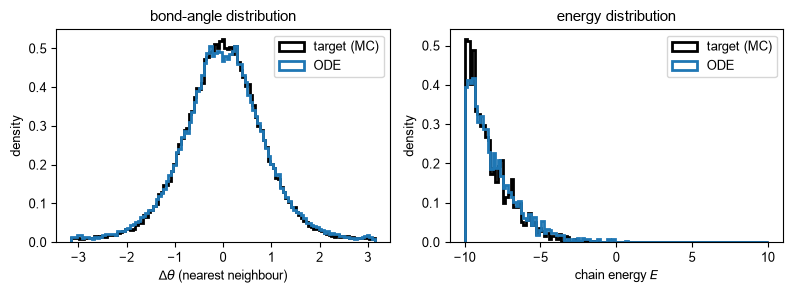

target (MC)   <E> = -12.5588   std(E) = 2.4397
ODE           <E> = -12.2761   std(E) = 2.5376
Exact         <E> = -12.5599


In [18]:
torch.manual_seed(19)
n_gen = 10_000
x0 = sample_base(n_gen, N, device=device)
gen_ode = model.sample(x0, n_steps=100)             # probability-flow ODE

fig, ax = plt.subplots(1, 2, figsize=(8, 3))
bins = np.linspace(-np.pi, np.pi, 120)
for x, lbl, c in [(x1_all, "target (MC)", "k"), (gen_ode, "ODE", "C0")]:
    ax[0].hist(dtheta(x), bins=bins, density=True, histtype="step", lw=2, label=lbl, color=c)
ax[0].set_xlabel(r"$\Delta\theta$ (nearest neighbour)"); ax[0].set_ylabel("density")
ax[0].set_title("bond-angle distribution"); ax[0].legend()

ebins = np.linspace(-N, N, 120)
for x, lbl, c in [(x1_all, "target (MC)", "k"), (gen_ode, "ODE", "C0")]:
    ax[1].hist(chain_energy(x, J), bins=ebins, density=True, histtype="step", lw=2, label=lbl, color=c)
ax[1].set_xlabel("chain energy $E$"); ax[1].set_ylabel("density")
ax[1].set_title("energy distribution"); ax[1].legend()
plt.tight_layout()
plt.show()

for x, lbl in [(x1_all, "target (MC)"), (gen_ode, "ODE")]:
    e = chain_energy(x, J)
    print(f"{lbl:12s}  <E> = {e.mean():+.4f}   std(E) = {e.std():.4f}")
print(f"{'Exact':12s}  <E> = {(N - 1) * (-J * (iv(1, J) / iv(0, J))):+.4f}")

### 5. Entropy estimates

The entropy change between base and target, estimated four different ways and compared against the exact $\Delta S = (N-1)\,[\log I_0(J) - J\,I_1(J)/I_0(J)]$.

entropy estimate (b·z)     : -5.1218 ± 0.0704
entropy estimate (b·s)     : -5.0711 ± 0.0420
entropy estimate (div b)   : -5.3343 ± 0.0364
entropy estimate (ODE div) : -5.1925 ± 0.0269
entropy estimate (ODE dot) : -4.8427 ± 0.0254
exact entropy: -5.1440


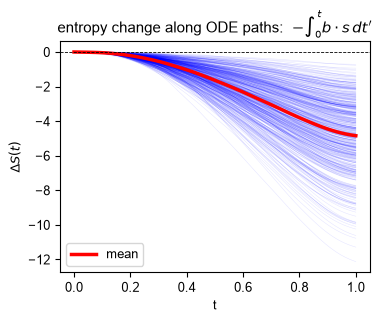

In [19]:

# first we do the generation-free version (batched)
torch.manual_seed(1414)
n_batches = 100
means_dot, means_div, means_zdot = np.zeros(n_batches), np.zeros(n_batches), np.zeros(n_batches)
x1_all.to(device)

for i in range(n_batches):
    idx = torch.randint(0, n_data, (batch_size,), device=device)
    x1 = x1_all[idx]
    x0 = sample_base(batch_size, N, device=device)
    x0, x1 = xy_ot_couple(x0, x1, batch=False)
    means_dot[i]  = model.entropy_estimate(x1, x0, "dot").mean().item()
    means_div[i]  = model.entropy_estimate(x1, x0, "div").mean().detach().item()
    means_zdot[i] = model.entropy_estimate(x1, x0, "zdot").mean().item()


strap = scipy.stats.bootstrap((means_dot,),np.mean,method='percentile')
err_dot = 0.5*(strap.confidence_interval.high-strap.confidence_interval.low)
strap = scipy.stats.bootstrap((means_zdot,),np.mean,method='percentile')
err_zdot = 0.5*(strap.confidence_interval.high-strap.confidence_interval.low)
strap = scipy.stats.bootstrap((means_div,),np.mean,method='percentile')
err_div = 0.5*(strap.confidence_interval.high-strap.confidence_interval.low)

print(f"entropy estimate (b·z)     : {np.mean(means_zdot):+.4f} ± {err_zdot:.4f}")
print(f"entropy estimate (b·s)     : {np.mean(means_dot):+.4f} ± {err_dot:.4f}")
print(f"entropy estimate (div b)   : {np.mean(means_div):+.4f} ± {err_div:.4f}")

# Running entropy change along many ODE paths.
n_batches = 100
npath = batch_size*n_batches
x0 = sample_base(npath, N, device=device)
traj, ent_traj, ts = model.sample(x0, n_steps=100, return_traj=True, entropy="div")
ts_c, ent_c_div = ts.cpu().numpy(), ent_traj.cpu().numpy()
ent_c_avg = ent_c_div[-1,:].mean()
strap = scipy.stats.bootstrap((ent_c_div[-1,:],),np.mean,method='percentile')
ent_c_err = 0.5*(strap.confidence_interval.high-strap.confidence_interval.low)

print(f"entropy estimate (ODE div) : {ent_c_avg:+.4f} ± {ent_c_err:.4f}")
traj, ent_traj, ts = model.sample(x0, n_steps=100, return_traj=True, entropy="dot")
ts_c, ent_c_dot = ts.cpu().numpy(), ent_traj.cpu().numpy()

ent_c_avg = ent_c_dot[-1,:].mean()
strap = scipy.stats.bootstrap((ent_c_dot[-1,:],),np.mean,method='percentile')
ent_c_err = 0.5*(strap.confidence_interval.high-strap.confidence_interval.low)
print(f"entropy estimate (ODE dot) : {ent_c_avg.mean():+.4f} ± {ent_c_err:.4f}")

dS = (N - 1) * (np.log(iv(0, J)) - J * (iv(1, J) / iv(0, J)))
print(f"exact entropy: {dS:+.4f}")

fig, ax = plt.subplots(figsize=(4, 3))
ax.plot(ts_c, ent_c_dot[:, :500], c="blue", lw=0.4, alpha=0.1)
ax.plot(ts_c, ent_c_dot.mean(axis=1), c="red", lw=2.5, label="mean")
ax.axhline(0.0, c="k", lw=0.6, ls="--")
ax.set_xlabel("t"); ax.set_ylabel(r"$\Delta S(t)$")
ax.set_title(r"entropy change along ODE paths:  $-\int_0^t b\cdot s\,dt'$")
ax.legend()
plt.show()

### 6. Other Values of N

In [21]:
chain_lengths   = np.array([1,2,4,8,16,32,64])
energies        = np.zeros_like(chain_lengths,dtype=np.float64)
entropies       = np.zeros_like(chain_lengths,dtype=np.float64)

n_gen = 1_000

for i,chain_length in enumerate(chain_lengths):
    print(chain_length)
    # sample base distribution and integrate, accumulating entropy
    x0 = sample_base(n_gen, chain_length, device=device)
    x1, ent = model.sample(x0, n_steps=50, entropy="dot")
    energies[i] = chain_energy(x1, J).mean()/float(chain_length)
    entropies[i] = ent.cpu().numpy().mean()/float(chain_length)

free_energies = energies - entropies

np.save("xy_energy.npy",energies)
np.save("xy_entropy.npy",entropies)


1
2
4
8
16
32
64


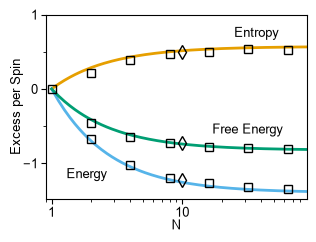

[0.03808646 0.01826654 0.0189284  0.02832978 0.02346828 0.02255998]
[-0.24688987 -0.09601257 -0.05467138 -0.07306705 -0.04156238 -0.05939138]
[-0.02657576 -0.01911889 -0.02311357 -0.03706463 -0.03172767 -0.03099163]
[0.07055566 0.04115741 0.02734177 0.03915177 0.02301287 0.03341509]


In [23]:
import matplotlib

okabe_ito = ['#E69F00', '#56B4E9', '#009E73', '#F0E442',
             '#0072B2', '#D55E00', '#CC79A7', '#000000']
plt.rcParams['axes.prop_cycle'] = plt.cycler(color=okabe_ito)
J = 2

fig,ax = plt.subplots(1,1,figsize=(3.0,2.25))


Nspace = np.linspace(1,2*np.amax(chain_lengths),1000)
ds = ((Nspace-1)/Nspace) * (np.log(iv(0,J))-J*(iv(1,J)/iv(0,J)))
de = ((Nspace-1)/Nspace) * (-J*(iv(1,J)/iv(0,J)))
df = de - ds
plt.plot(Nspace,-ds,label=r'$-\Delta \tilde{s}$',ms=5,lw=2)
plt.plot(Nspace,de,label=r"$\Delta \tilde{u}$",ms=5,lw=2)
plt.plot(Nspace,df,label=r"$\Delta \tilde{f}$",ms=5,lw=2)

plt.plot(chain_lengths[1:],energies[1:],'ks',mfc='none',lw=1.5)
plt.plot(chain_lengths[1:],-entropies[1:],'ks',mfc='none',lw=1.5)
plt.plot(chain_lengths[1:],free_energies[1:],'ks',mfc='none',lw=1.5)
plt.plot(1,0,'ks',mfc='none')

plt.plot(10,-1.23193,'kd',mfc='none',ms=7)
plt.plot(10,0.49887,'kd',mfc='none',ms=7)
plt.plot(10,-1.23193+0.49887,'kd',mfc='none',ms=7)


plt.xticks([1]+chain_lengths.tolist())
plt.xlim(0.9,1.4*np.amax(chain_lengths))
plt.xscale('log')
ax.xaxis.set_major_formatter(matplotlib.ticker.FormatStrFormatter("%d"))
ax.yaxis.set_minor_formatter(matplotlib.ticker.ScalarFormatter())

#leg = plt.legend(frameon=False,loc=(0.65,0.45),
#                    handlelength=1)
#renderer = fig.canvas.get_renderer()
#max_width = max([t.get_window_extent().width for t in leg.get_texts()])
#for text in leg.get_texts():
#    text.set_ha("right")
#    text.set_position((-max_width, 0))

plt.text(25,0.7,"Entropy")
plt.text(1.3,-1.2,"Energy")
plt.text(17,-0.6,"Free Energy")

plt.xlabel(r'N',labelpad=0)
plt.ylabel('Excess per Spin',labelpad=0)
plt.yticks([-1,0,1])
plt.yticks([-0.5,0.5], minor=True)
plt.setp(ax.get_yminorticklabels(), visible=False)
ax.tick_params(pad=2)
plt.tight_layout()
plt.subplots_adjust(0.12,0.15,0.99,0.97)

#plt.savefig("XY_chain.eps",dpi=600)
#plt.savefig("XY_chain.png",dpi=600)
plt.show()



exact_ds = ((chain_lengths[1:]-1)/chain_lengths[1:]) * (np.log(iv(0,J))-J*(iv(1,J)/iv(0,J)))
exact_de = ((chain_lengths[1:]-1)/chain_lengths[1:]) * (-J*(iv(1,J)/iv(0,J)))

err_de = (exact_de-energies[1:])/exact_de
err_ds = (-exact_ds+entropies[1:])/exact_ds
print(err_de)
print(err_ds)

diff_de = (exact_de-energies[1:])
diff_ds = (-exact_ds+entropies[1:])
print(diff_de)
print(diff_ds)


### 7.Ablation

In [ ]:
n_samples = [1,3,10,30,100,300,1000,3000,10000]

N = 10           # chain length
J = 2.0          # ferromagnetic coupling of the target Boltzmann distribution
batch_size = 512 # same for all

estimates = []

for n_sample in n_samples:
    x1 = load_exact_data(N,J,n_sample).to(device)
    n_data = x1.shape[0]
    torch.seed()

    # Model definition
    model = make_model(
        n_neighbors=2, hidden=16, mlp_layers=3, n_layers=3, edge_order=8, time_order=8,
        path="linear", gamma="sqrt", gamma_scale=0.2,
        score_div_method="exact",
    ).to(device)

    # train it
    model, total_hist = train(x1, model=model, steps=10_000, batch=batch_size, lr=1e-4, batch_ot=False,
    device=str(device), log_every=1000, entropy="both")

    n_batches = 100
    means = []

    for _ in range(n_batches):
        idx = torch.randint(0, n_data, (batch_size,), device=device)
        x1_sample = x1[idx]
        x0 = sample_base(batch_size, N, device=device)
        x0, x1_sample = xy_ot_couple(x0, x1_sample, batch=False)
        means.append(model.entropy_estimate(x1_sample, x0, "zdot").mean().item())
    estimates.append(means)

np.save(f"ablation.npy",np.array(estimates))

  step     0  loss_b   -0.0008  loss_s    0.0025  S_dot    0.0000  S_zdot   -0.0008  transport   5.800  (  0.1s)
  step  1000  loss_b   -2.3985  loss_s   -5.8865  S_dot   -3.8271  S_zdot   -4.2726  transport   5.645  ( 24.4s)
  step  2000  loss_b   -3.8272  loss_s  -20.1426  S_dot   -6.0527  S_zdot   -8.6679  transport   5.731  ( 49.0s)
  step  3000  loss_b   -4.0730  loss_s  -34.8445  S_dot   -7.3625  S_zdot  -10.5544  transport   5.699  ( 73.4s)
  step  4000  loss_b   -4.2170  loss_s  -48.2857  S_dot   -7.0378  S_zdot  -12.0577  transport   5.686  ( 97.8s)
  step  5000  loss_b   -4.3347  loss_s  -62.7300  S_dot   -7.0923  S_zdot  -14.2233  transport   5.749  (122.2s)
  step  6000  loss_b   -4.3774  loss_s  -77.5856  S_dot   -7.3080  S_zdot  -15.5003  transport   5.629  (146.5s)
  step  7000  loss_b   -4.4188  loss_s  -89.5223  S_dot   -7.6565  S_zdot  -16.2190  transport   5.760  (170.4s)
  step  8000  loss_b   -4.4431  loss_s -100.4495  S_dot   -7.9715  S_zdot  -16.9008  transport  

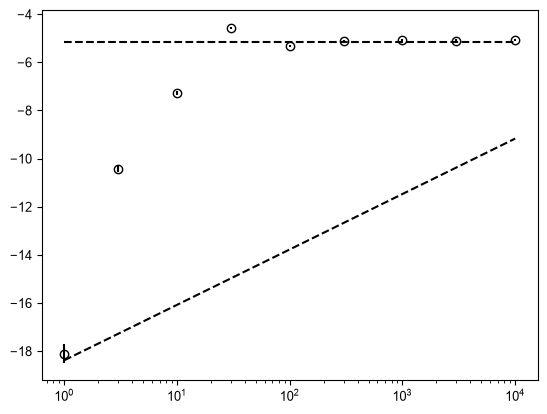

In [47]:
import scipy.stats
res = np.load(f"ablation.npy")
n_samples = [1,3,10,30,100,300,1000,3000,10000]
ds_n = res.mean(axis=1)
ds_n_err = []
for row in res:
    res = scipy.stats.bootstrap((row,),np.mean,method='percentile')
    ds_n_err.append(0.5*(res.confidence_interval.high-res.confidence_interval.low))
plt.errorbar(n_samples,ds_n,yerr=ds_n_err,fmt='ko',mfc='none')
nspace = np.geomspace(1,10000,100)
plt.plot(nspace,-5.144*np.ones_like(nspace),'--k')
plt.plot(nspace,np.log(nspace)-10*np.log(2*np.pi),'--k')
plt.xscale('log')
plt.show()

